In [68]:
# importing the packages
import numpy as np
import pandas as pd
from itertools import chain
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

In [69]:
# read the pairings.txt file
# Open the file in read mode
with open("../data/subset_pairings/subset_pairings.txt", "r") as file:
    lines = file.readlines()

# convert each line (representing a list) to an actual list
pairings = [eval(line) for line in lines]

# sort pairings based on the first element of each list
pairings.sort(key=lambda x: x[0])

In [70]:
# read the flight leg data
np_arr = pd.read_csv(
    "../data/flight_legs/data.csv",
    parse_dates=["start_time", "end_time"],
).to_numpy()

departure_time = [[np_arr[j][3] for j in i] for i in pairings]
flight_leg_id = [[np_arr[j][0] for j in i] for i in pairings]
departure_airport = [[np_arr[j][1] for j in i] for i in pairings]
destination_airport = [[np_arr[j][2] for j in i] for i in pairings]

In [71]:
# find the max and min departure time from the list of list
max_departure_time = max(list(chain(*departure_time)))
min_departure_time = min(list(chain(*departure_time)))

In [72]:
# convert to a dictionary where key is the 'sub_pair' & index +1
pairings_dict = {f"P{i+1}": pair for i, pair in enumerate(departure_time)}

In [73]:
# sort the pairing dictionary based on the first timestamp
pairings_dict = dict(sorted(pairings_dict.items(), key=lambda item: item[1][0]))
print(pairings_dict)

{'P12': [Timestamp('2024-03-11 01:00:00'), Timestamp('2024-03-11 05:00:00'), Timestamp('2024-03-11 08:00:00'), Timestamp('2024-03-11 23:00:00'), Timestamp('2024-03-12 03:00:00'), Timestamp('2024-03-12 06:00:00'), Timestamp('2024-03-12 22:00:00'), Timestamp('2024-03-13 02:00:00'), Timestamp('2024-03-13 05:00:00'), Timestamp('2024-03-13 20:00:00'), Timestamp('2024-03-14 00:00:00'), Timestamp('2024-03-14 03:00:00')], 'P6': [Timestamp('2024-03-11 03:00:00'), Timestamp('2024-03-11 07:00:00'), Timestamp('2024-03-11 10:00:00'), Timestamp('2024-03-12 01:00:00'), Timestamp('2024-03-12 05:00:00'), Timestamp('2024-03-12 08:00:00'), Timestamp('2024-03-13 00:00:00'), Timestamp('2024-03-13 04:00:00'), Timestamp('2024-03-13 07:00:00'), Timestamp('2024-03-13 22:00:00'), Timestamp('2024-03-14 02:00:00'), Timestamp('2024-03-14 05:00:00')], 'P8': [Timestamp('2024-03-11 03:00:00'), Timestamp('2024-03-11 07:00:00'), Timestamp('2024-03-11 10:00:00'), Timestamp('2024-03-12 01:00:00'), Timestamp('2024-03-12 0

In [87]:
# create a figure and axis
def plot_departure(ax):
    ax.annotate(
        f"{departure_airport[i][j]}",
        xy=(x, y),
        xytext=(x, y - 0.15),
        textcoords="data",
        ha="right",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )


def plot_destination(ax):
    ax.annotate(
        f"{destination_airport[i][j]}",
        xy=(x, y),
        xytext=(x + pd.Timedelta(minutes=30), y - 0.275),
        textcoords="data",
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold",
    )


def plot_flight_leg_id(ax, distance=pd.Timedelta(minutes=0)):
    ax.annotate(
        f"{flight_leg_id[i][j]}",
        xy=(x, y),
        xytext=(x + distance, y + 0.3),
        textcoords="data",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

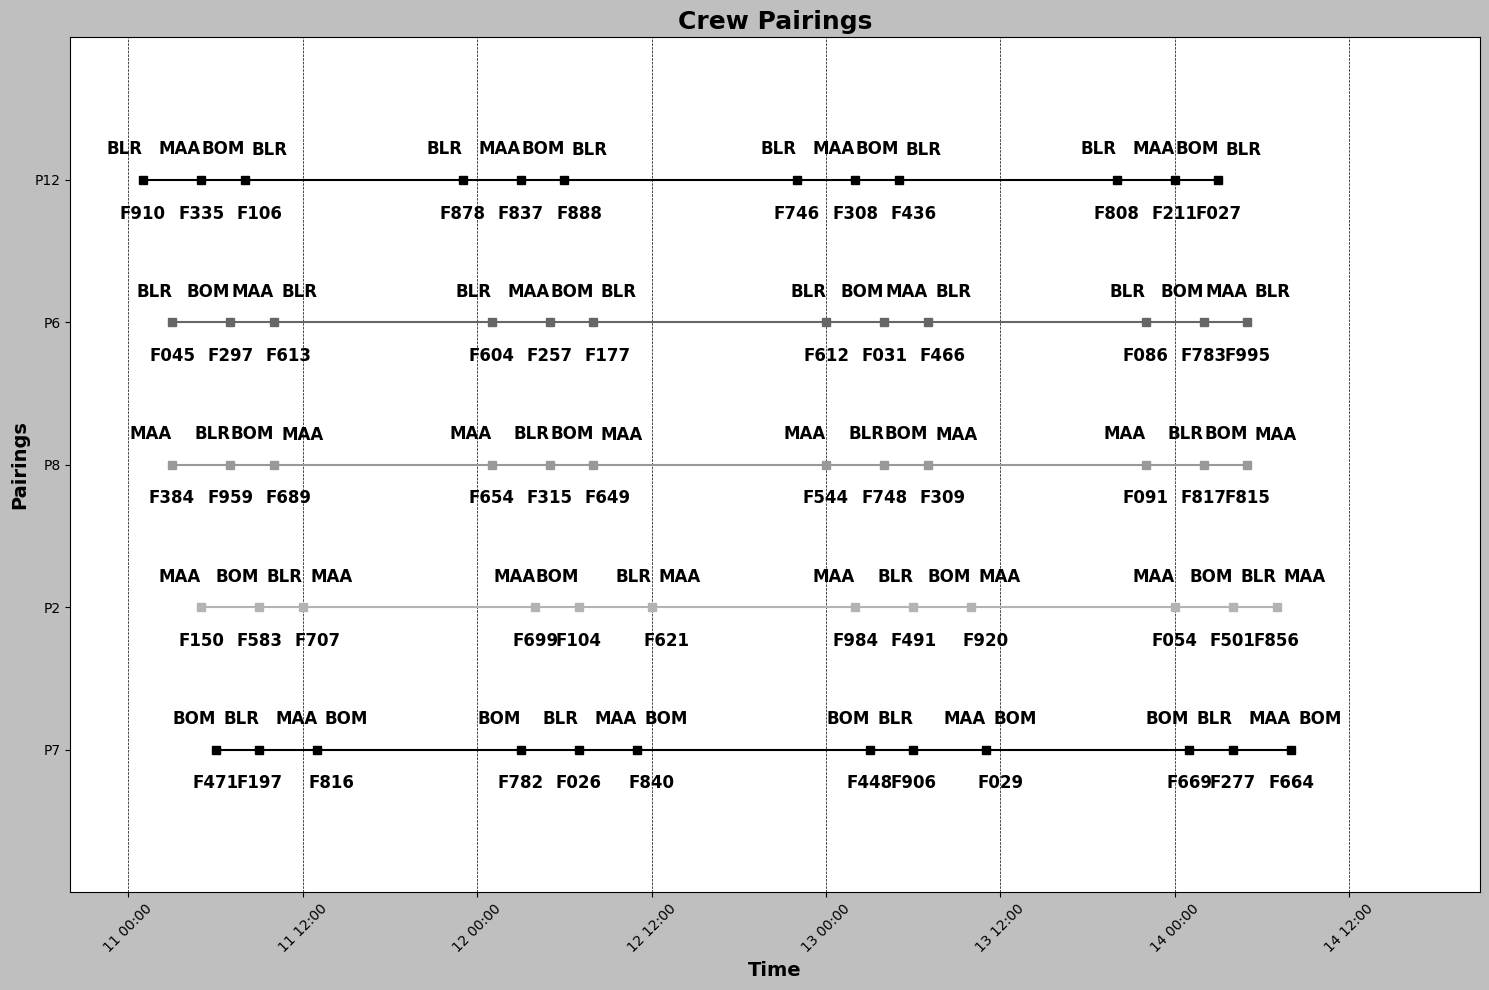

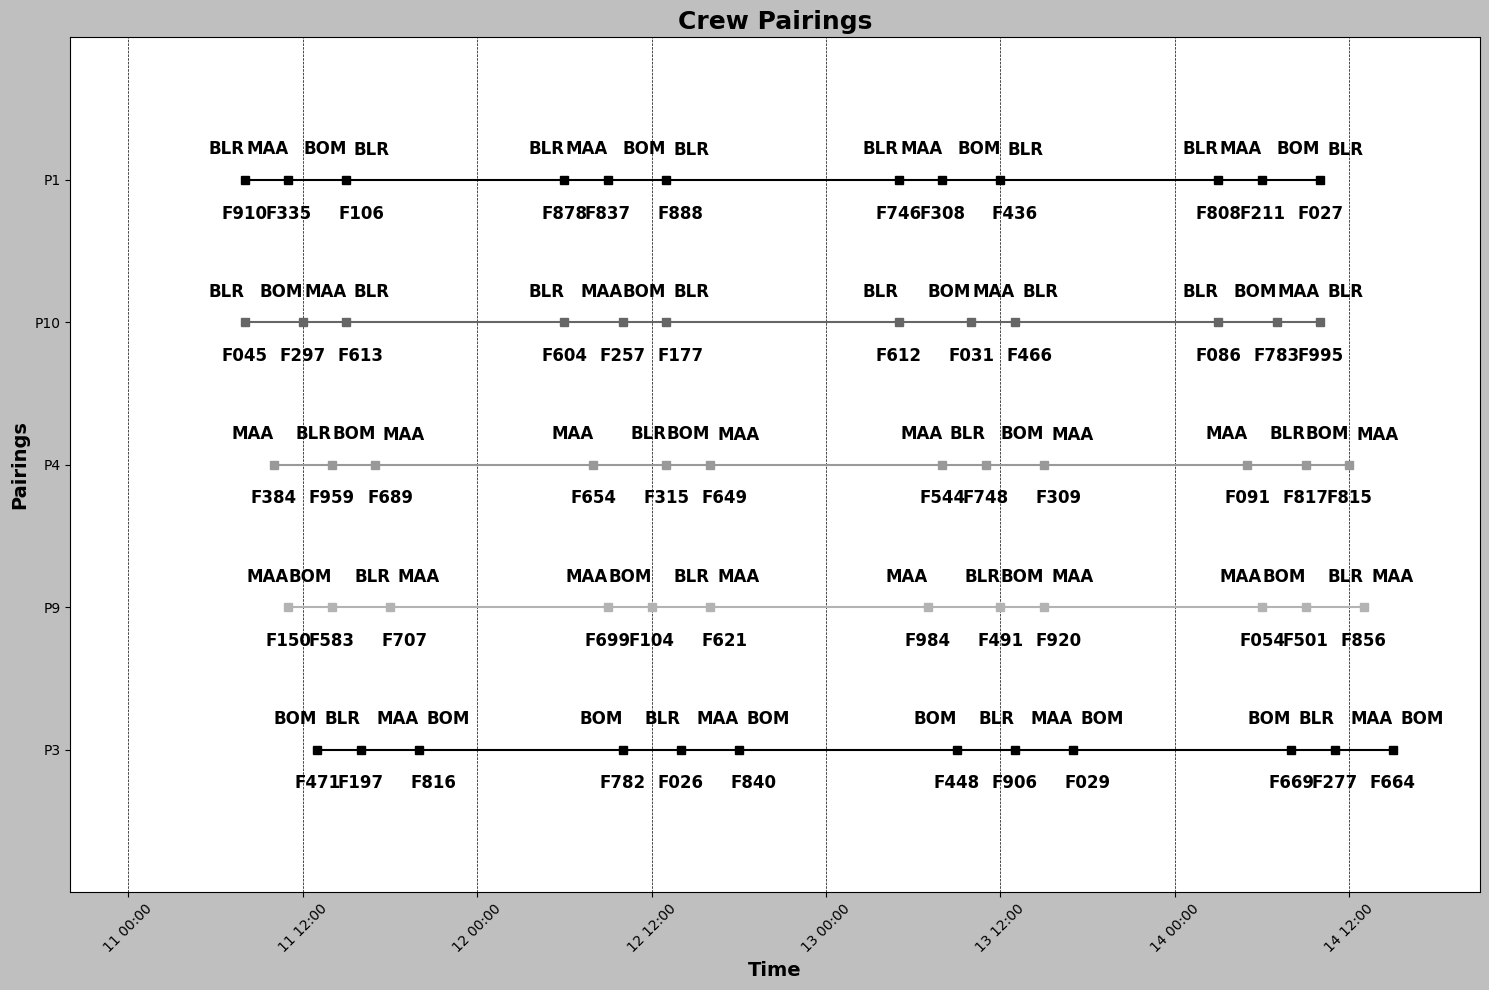

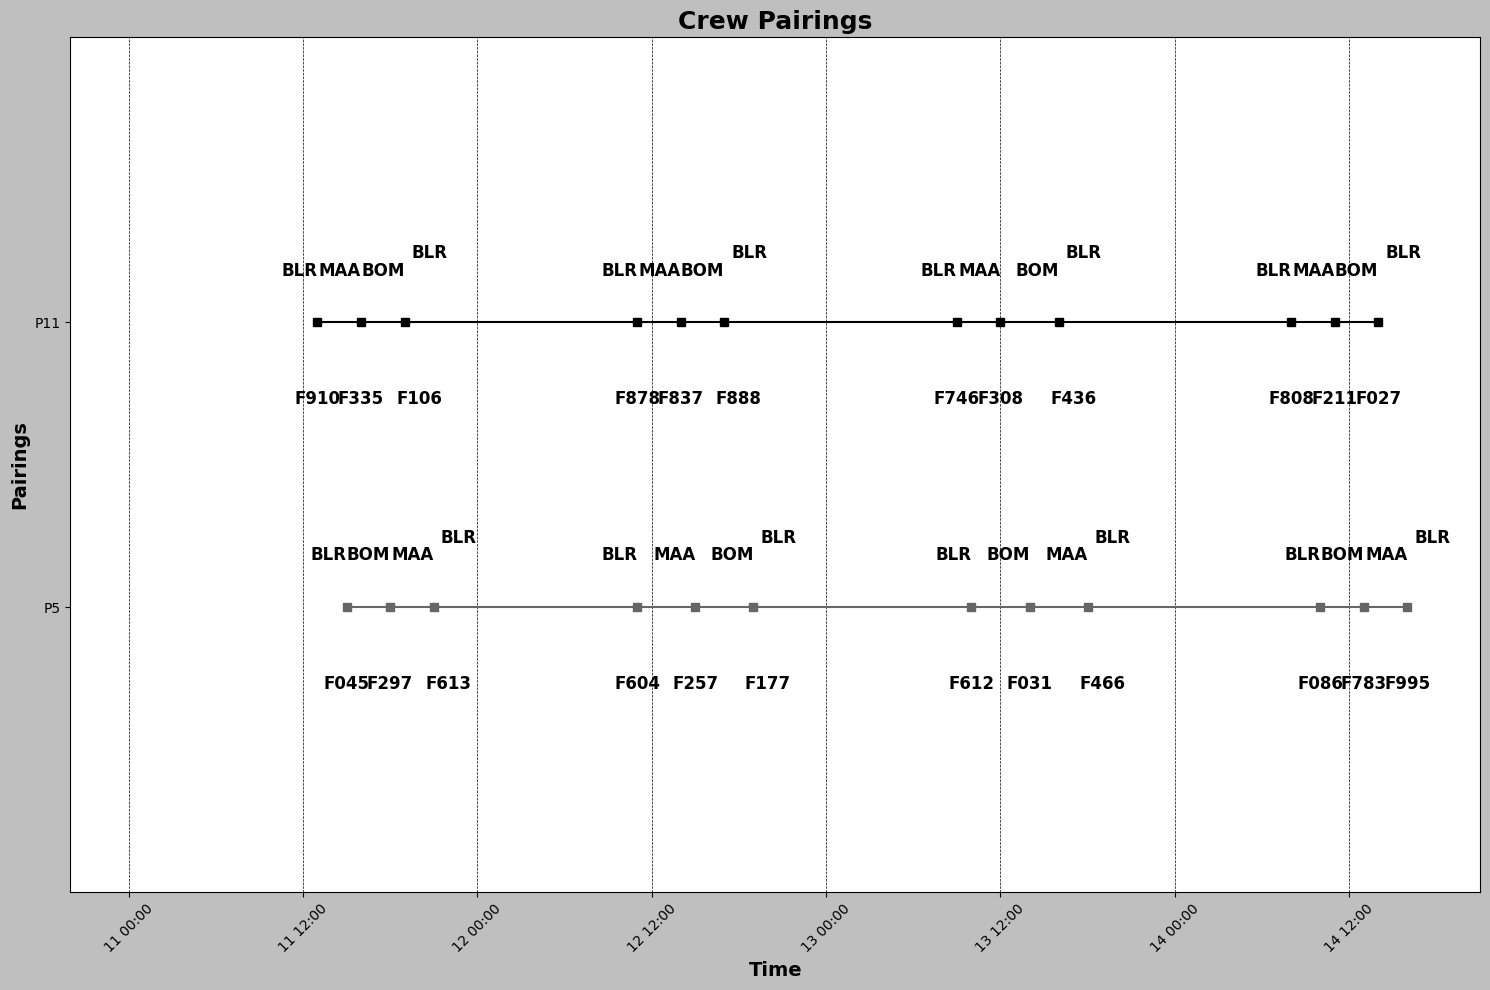

In [91]:
for a in range(0, len(pairings_dict), 5):
    # get the keys
    Keys = list(pairings_dict.keys())[a : a + 5]
    # get the values
    # create a new dict with subset of keys
    pairings_dict_subset = {k: pairings_dict[k] for k in Keys}
    # Plotting
    # make the entire plot black and white
    plt.style.use("grayscale")
    fig = plt.figure(figsize=(15, 10))

    ax = fig.add_subplot()

    # Iterate over dictionary items and plot

    for i, (key, value) in enumerate(pairings_dict_subset.items()):

        ax.plot(value, [i] * len(value), marker="s", label=key)

        for j, (x, y) in enumerate(zip(value, [i] * len(value))):

            try:
                if value[j + 1] - value[j] == pd.Timedelta(hours=4):
                    plot_departure(ax)
                    plot_flight_leg_id(ax)
                elif value[j + 1] - value[j] == pd.Timedelta(hours=3):
                    plot_departure(ax)
                    plot_flight_leg_id(ax)
                elif value[j + 1] - value[j] <= pd.Timedelta(hours=6):
                    plot_departure(ax)
                    plot_flight_leg_id(ax)
                else:
                    plot_departure(ax)
                    plot_destination(ax)
                    plot_flight_leg_id(ax, pd.Timedelta(minutes=60))

            except:
                plot_departure(ax)
                plot_destination(ax)
                plot_flight_leg_id(ax)

    # Set y-axis ticks and labels

    ax.set_yticks(range(len(pairings_dict_subset)))

    ax.set_yticklabels(pairings_dict_subset.keys())

    # add space from the bottom and the top
    plt.ylim(bottom=-1, top=len(pairings_dict_subset))
    plt.xlim(
        min_departure_time - pd.Timedelta(hours=5),
        max_departure_time + pd.Timedelta(hours=5),
    )

    # Set x-axis date format

    date_format = DateFormatter("%d %H:%M")

    ax.xaxis.set_major_formatter(date_format)

    plt.xticks(rotation=45)

    # add  vertical grid lines only for the days
    ax.xaxis.grid(True, which="major", linestyle="--", linewidth=0.5)

    # plot in reverse order
    ax.invert_yaxis()

    # Set labels and title

    plt.xlabel("Time", fontweight="bold", fontsize=14)

    plt.ylabel("Pairings", fontweight="bold", fontsize=14)

    plt.title("Crew Pairings", fontweight="bold", fontsize=18)

    # Show plot

    plt.tight_layout()
    plt.savefig(f"../data/network_plot/network_plot{a}.png")
    plt.show()